# Housing Prices machine learning prediction model

# Importing libraries and loading data

In [2]:
# Importing libraries for data visualization and data manipulation
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings as wr
import itertools
# Importing libraries for data preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

# Importing libraries for model selection
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV, RepeatedStratifiedKFold, KFold

# Importing libraries for AI models

from sklearn.linear_model import LinearRegression, LassoCV, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
# Importing libraries for better model performance 

from xgboost import XGBRegressor

# Importing libraries for feature selection
from sklearn.feature_selection import mutual_info_regression
from sklearn.compose import ColumnTransformer  
from sklearn.pipeline import Pipeline
# Importing libraries for evaluation metrics

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_log_error,\
                            adjusted_rand_score, mean_absolute_percentage_error, make_scorer

plt.style.use('ggplot')
wr.filterwarnings('ignore')

# Data loading

## Loading train and test data set

In [3]:
train_path = 'D:/Programming/Housing Prices Predication using machin learning/home-data-for-ml-course/train.csv'
test_path = 'D:/Programming/Housing Prices Predication using machin learning/home-data-for-ml-course/test.csv'

data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

## Data intergration

In [4]:
df = pd.concat([data_train, data_test]).reset_index()

pd.set_option('display.max_columns', None) # Displaying everysingle columns

# Data wrangling

In [5]:
int_features = pd.Series(df.select_dtypes(include = ['int64']).columns)
cat_features = df.select_dtypes(include = ['object']).columns
float_features = pd.Series(df.select_dtypes(include = ['float64']).columns)
int_features = int_features[int_features != 'index']
num_features = pd.concat([int_features, float_features], axis=0)
num_features

1                Id
2        MSSubClass
3           LotArea
4       OverallQual
5       OverallCond
6         YearBuilt
7      YearRemodAdd
8          1stFlrSF
9          2ndFlrSF
10     LowQualFinSF
11        GrLivArea
12         FullBath
13         HalfBath
14     BedroomAbvGr
15     KitchenAbvGr
16     TotRmsAbvGrd
17       Fireplaces
18       WoodDeckSF
19      OpenPorchSF
20    EnclosedPorch
21        3SsnPorch
22      ScreenPorch
23         PoolArea
24          MiscVal
25           MoSold
26           YrSold
0       LotFrontage
1        MasVnrArea
2        BsmtFinSF1
3        BsmtFinSF2
4         BsmtUnfSF
5       TotalBsmtSF
6      BsmtFullBath
7      BsmtHalfBath
8       GarageYrBlt
9        GarageCars
10       GarageArea
11        SalePrice
dtype: object

## Data cleaning

<Axes: >

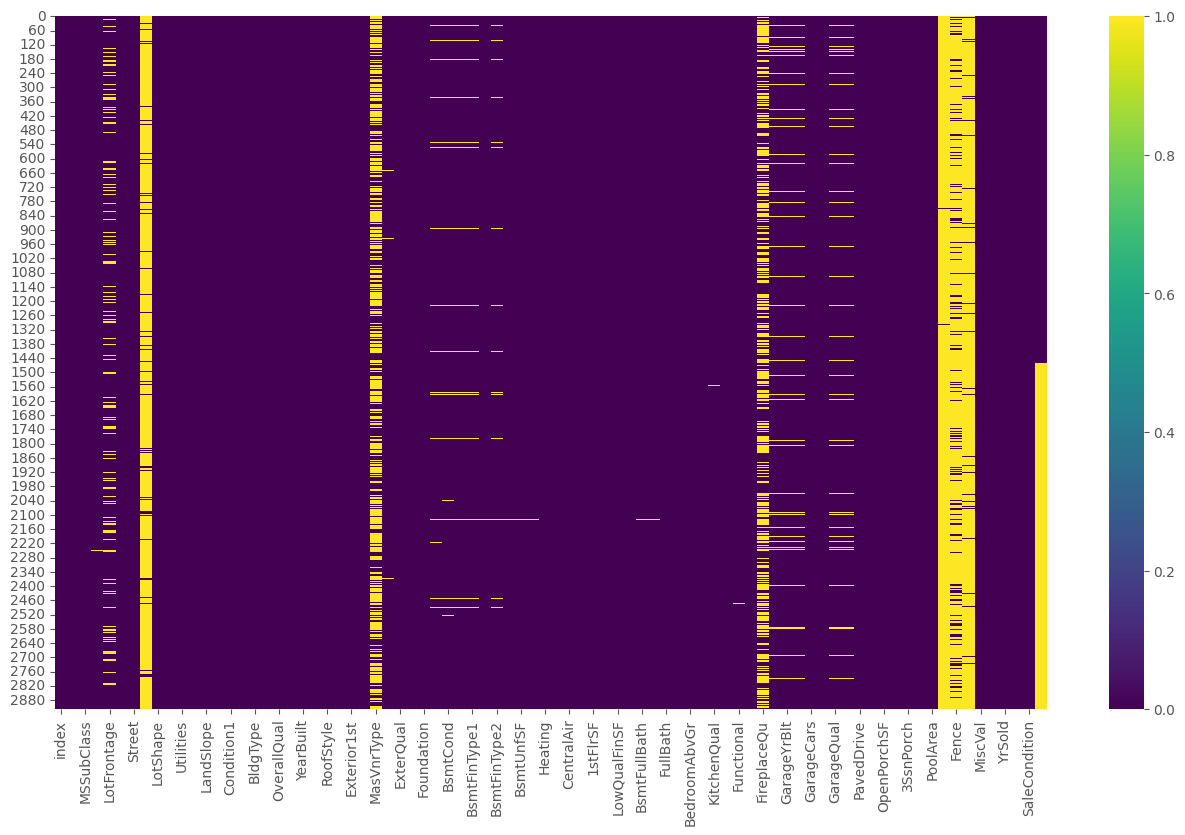

In [6]:
# Visualizing the missing values
plt.figure(figsize = (16, 9))
na_corr = df.isna()
sns.heatmap(na_corr, cmap = 'viridis')

**Some insights**
- 'PoolQc', 'Alley' and 'MiscFeature' seem to be containing a lot of missing values
- 'Exterior2nd' and Fireplaces features are also containing a lot of missing values

### Getting the null value percentages

In [7]:
na_list = df.isna().sum().sort_values(ascending = False)
na_list

PoolQC           2909
MiscFeature      2814
Alley            2721
Fence            2348
MasVnrType       1766
                 ... 
EnclosedPorch       0
MoSold              0
MiscVal             0
YrSold              0
SaleCondition       0
Length: 82, dtype: int64

In [8]:
# getting the percentages
na_list_percent = na_list / df.shape[0] * 100

In [9]:
missing_50 = na_list_percent[na_list_percent >= 50]
missing_50

PoolQC         99.657417
MiscFeature    96.402878
Alley          93.216855
Fence          80.438506
MasVnrType     60.500171
dtype: float64

In [10]:
missing_20 = na_list_percent[(na_list_percent >= 20) & (na_list_percent <50)]
missing_20

SalePrice      49.982871
FireplaceQu    48.646797
dtype: float64

In [11]:
missing_5 = na_list_percent[(na_list_percent <= 5) & (na_list_percent >0)]
missing_5

BsmtExposure    2.809181
BsmtCond        2.809181
BsmtQual        2.774923
BsmtFinType2    2.740665
BsmtFinType1    2.706406
MasVnrArea      0.787941
MSZoning        0.137033
BsmtFullBath    0.068517
Functional      0.068517
Utilities       0.068517
BsmtHalfBath    0.068517
SaleType        0.034258
KitchenQual     0.034258
BsmtFinSF2      0.034258
BsmtFinSF1      0.034258
TotalBsmtSF     0.034258
BsmtUnfSF       0.034258
Exterior2nd     0.034258
Exterior1st     0.034258
GarageCars      0.034258
GarageArea      0.034258
Electrical      0.034258
dtype: float64

### Data imputation

In [12]:
# Instead of dropping columns NA values we will fill them some constant values
na_list_percent = na_list_percent[na_list_percent > 0]
print('The number of features have NA values is:',len(na_list_percent))
na_list_percent

The number of features have NA values is: 35


PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
SalePrice       49.982871
FireplaceQu     48.646797
LotFrontage     16.649538
GarageYrBlt      5.447071
GarageCond       5.447071
GarageQual       5.447071
GarageFinish     5.447071
GarageType       5.378554
BsmtExposure     2.809181
BsmtCond         2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MasVnrArea       0.787941
MSZoning         0.137033
BsmtFullBath     0.068517
Functional       0.068517
Utilities        0.068517
BsmtHalfBath     0.068517
SaleType         0.034258
KitchenQual      0.034258
BsmtFinSF2       0.034258
BsmtFinSF1       0.034258
TotalBsmtSF      0.034258
BsmtUnfSF        0.034258
Exterior2nd      0.034258
Exterior1st      0.034258
GarageCars       0.034258
GarageArea       0.034258
Electrical       0.034258
dtype: float64

In [13]:
missing_cat = na_list_percent[na_list_percent.keys().isin(cat_features)]
print('The number of categorical feature have NA values is:', len(missing_cat))
missing_cat

The number of categorical feature have NA values is: 23


PoolQC          99.657417
MiscFeature     96.402878
Alley           93.216855
Fence           80.438506
MasVnrType      60.500171
FireplaceQu     48.646797
GarageCond       5.447071
GarageQual       5.447071
GarageFinish     5.447071
GarageType       5.378554
BsmtExposure     2.809181
BsmtCond         2.809181
BsmtQual         2.774923
BsmtFinType2     2.740665
BsmtFinType1     2.706406
MSZoning         0.137033
Functional       0.068517
Utilities        0.068517
SaleType         0.034258
KitchenQual      0.034258
Exterior2nd      0.034258
Exterior1st      0.034258
Electrical       0.034258
dtype: float64

In [14]:
missing_int = na_list_percent[na_list_percent.keys().isin(int_features)]
print('The number of categorical feature have NA values is:', len(missing_int))
missing_int

The number of categorical feature have NA values is: 0


Series([], dtype: float64)

In [15]:
missing_float = na_list_percent[na_list_percent.keys().isin(float_features)]
print('The number of categorical feature have NA values is:', len(missing_float))
missing_float

The number of categorical feature have NA values is: 12


SalePrice       49.982871
LotFrontage     16.649538
GarageYrBlt      5.447071
MasVnrArea       0.787941
BsmtFullBath     0.068517
BsmtHalfBath     0.068517
BsmtFinSF2       0.034258
BsmtFinSF1       0.034258
TotalBsmtSF      0.034258
BsmtUnfSF        0.034258
GarageCars       0.034258
GarageArea       0.034258
dtype: float64

In [16]:
# Making a copy of the data set 
dfc = df.copy()

#### Categorical data

In [17]:
def BefvsAft(col):
    plt.figure(figsize=(12, 5))
    plt.suptitle(col)

    # Displaying the data before imputation
    plt.subplot(1, 2, 1)
    sns.countplot(data = df, x= col, palette= 'viridis')
    plt.title('Before')
    
    # Displaying the data after imputation
    plt.subplot(1, 2, 2)
    sns.countplot(data = dfc, x = col, palette = 'viridis')
    plt.title('After')

    plt.tight_layout()
    plt.show()


##### MSZoning

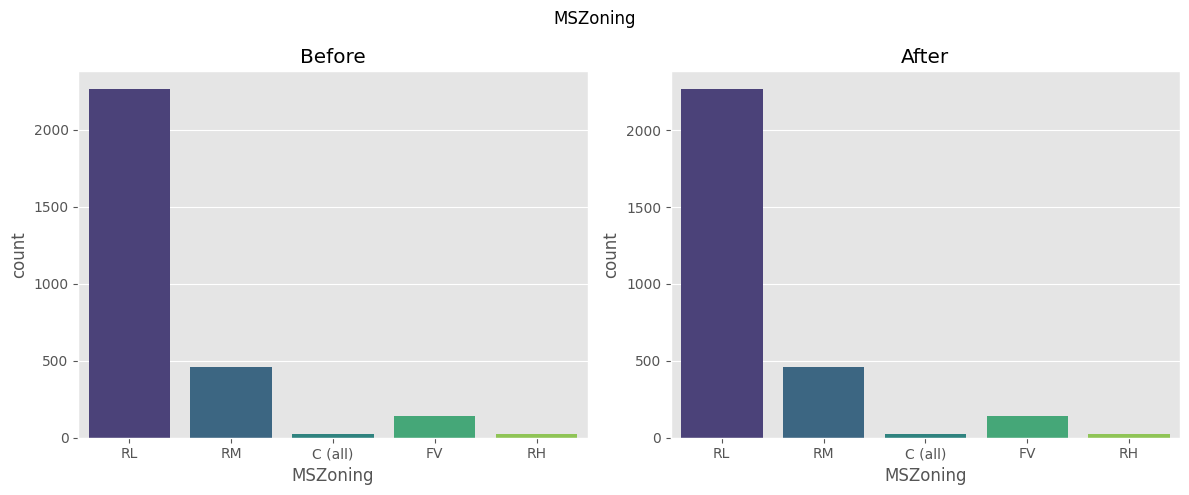

In [18]:
# Handling MSZoning with the mode value
MSZoning_mode = dfc['MSZoning'].mode()[0]
dfc['MSZoning'].fillna(MSZoning_mode, inplace=True)
BefvsAft('MSZoning')

##### Alley

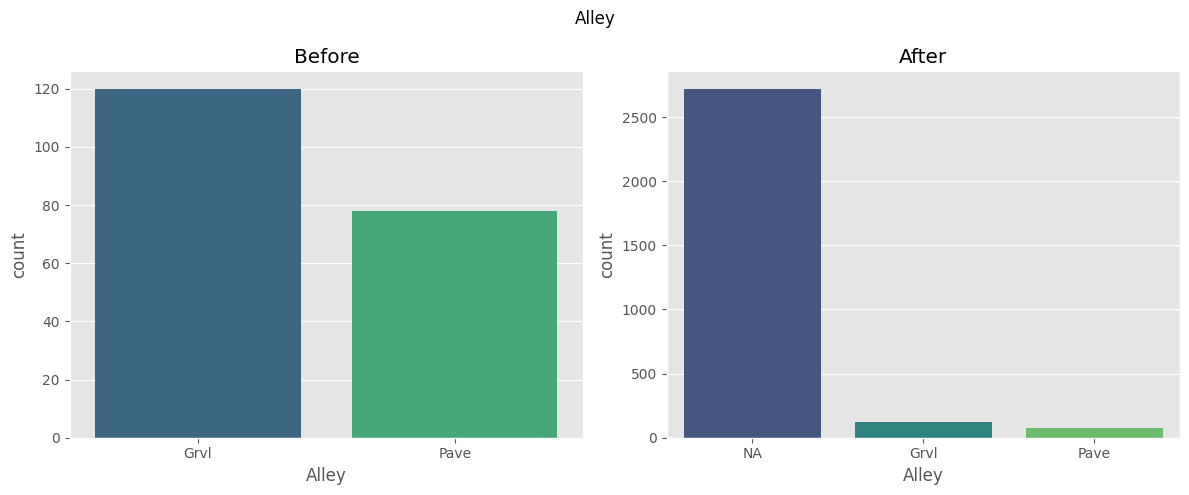

In [19]:
cont_alley = 'NA'
dfc['Alley'].fillna(cont_alley, inplace = True)
BefvsAft('Alley')

##### Utilities

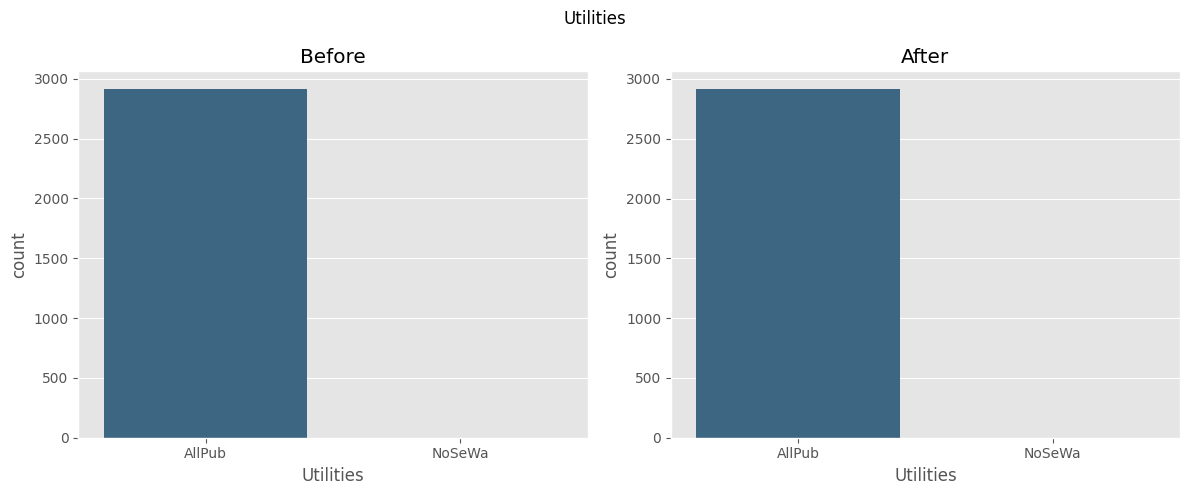

In [20]:
cont_ult = df['Utilities'].mode()[0]
dfc['Utilities'].fillna(cont_ult, inplace= True)
BefvsAft('Utilities')

##### Exterior1st and 2nd

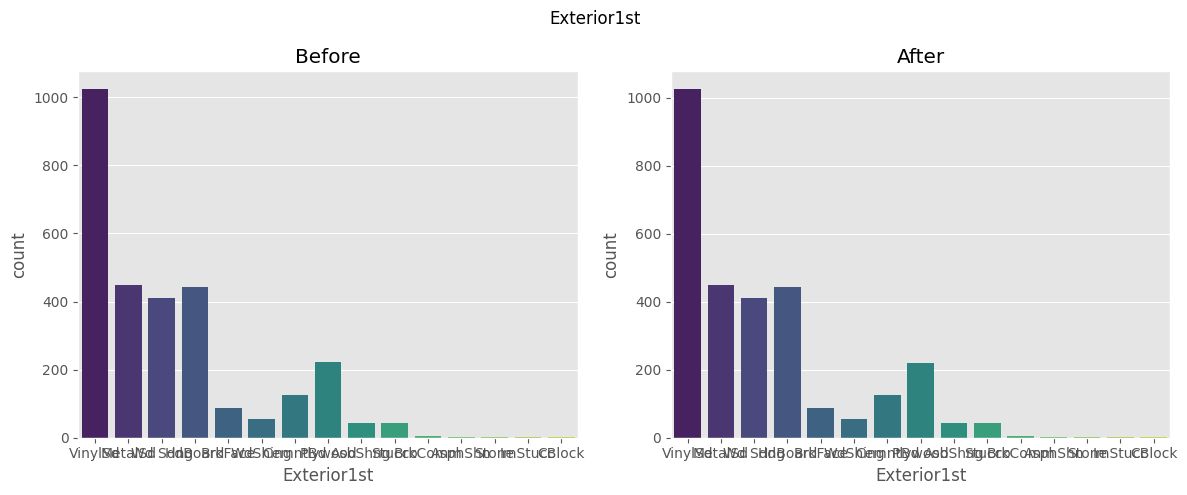

In [21]:
cont_exterior1st = df['Exterior1st'].mode()[0]
dfc['Exterior1st'].fillna(cont_exterior1st, inplace=True)
BefvsAft('Exterior1st')

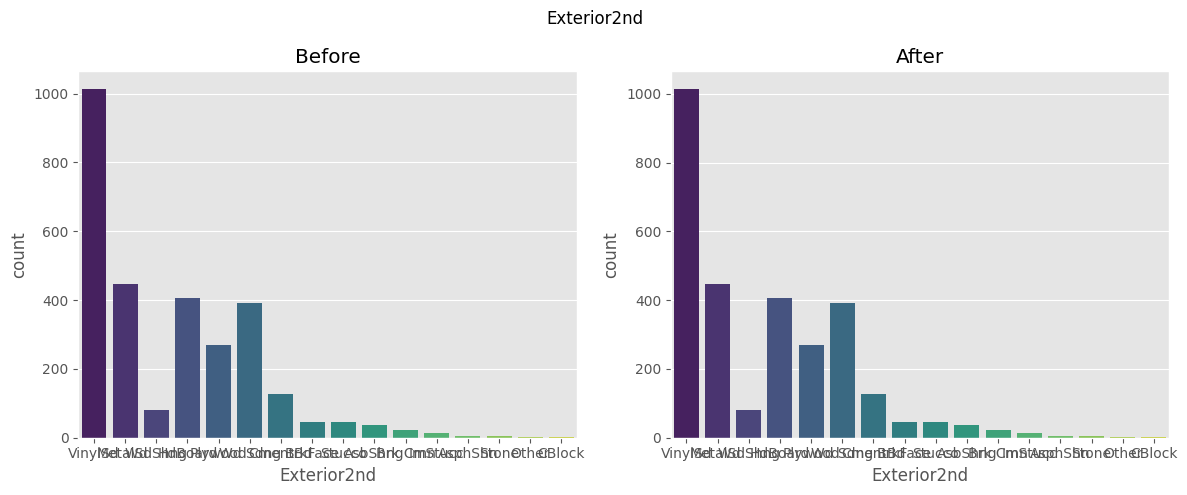

In [22]:
cont_exterior2nd = df['Exterior2nd'].mode()[0]
dfc['Exterior2nd'].fillna(cont_exterior2nd, inplace=True)
BefvsAft('Exterior2nd')

#### Numerical data

In [23]:
# Using basic statistics to identify outliers
def calc_outlier_percentage(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = (col < lower) | (col> upper)
    outlier_percentage = outliers.mean() * 100

    return outlier_percentage

In [24]:
# Function to compare the distribution of numerical data before and after data imputation

def BefvsAftNum(col):

    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    plt.suptitle(col)

    # Box plot
    sns.boxplot(data= df, x = col, ax= ax[0, 0])
    plt.title('Before')

    sns.boxplot(data= dfc, x = col, ax= ax[1, 0])
    plt.title('After')

    # KDE plot
    sns.kdeplot(data = df, x = col, ax= ax[0, 1])
    sns.histplot(data= df, x= col, stat='density', ax= ax[0, 1], color = 'blue', edgecolor='black')
    plt.title('Before')

    sns.kdeplot(data = dfc, x = col, ax= ax[1, 1])
    sns.histplot(data= dfc, x= col, stat='density', ax = ax[1, 1], color = 'blue', edgecolor='black')
    plt.title('After')

    plt.tight_layout()
    plt.show()

In [25]:
df[missing_float.index].apply(calc_outlier_percentage).sort_values(ascending=False)

BsmtFinSF2      11.887633
MasVnrArea       6.851662
LotFrontage      6.783145
BsmtHalfBath     5.995204
TotalBsmtSF      4.179514
SalePrice        2.089757
BsmtUnfSF        1.815690
GarageArea       1.438849
GarageCars       0.582391
BsmtFinSF1       0.513875
GarageYrBlt      0.102775
BsmtFullBath     0.068517
dtype: float64

- BsmtFinSF2, MasVnrArea, LotFrontage and BsmatHalfBath has the most amounf of outliers (percentage > 5) --> replacing the na value with median value
- The rest use mean value

##### Lot Frontage

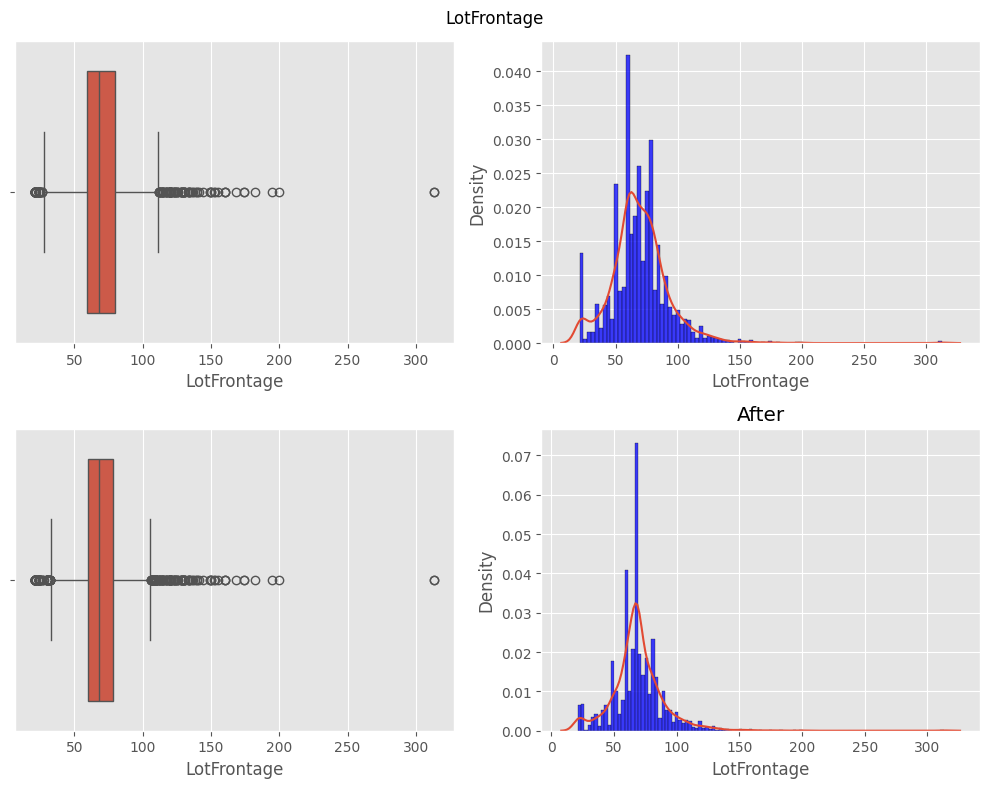

In [26]:
cont_lot = df['LotFrontage'].median()
dfc['LotFrontage'].fillna(cont_lot, inplace= True)
BefvsAftNum('LotFrontage')

##### MasVnrArea

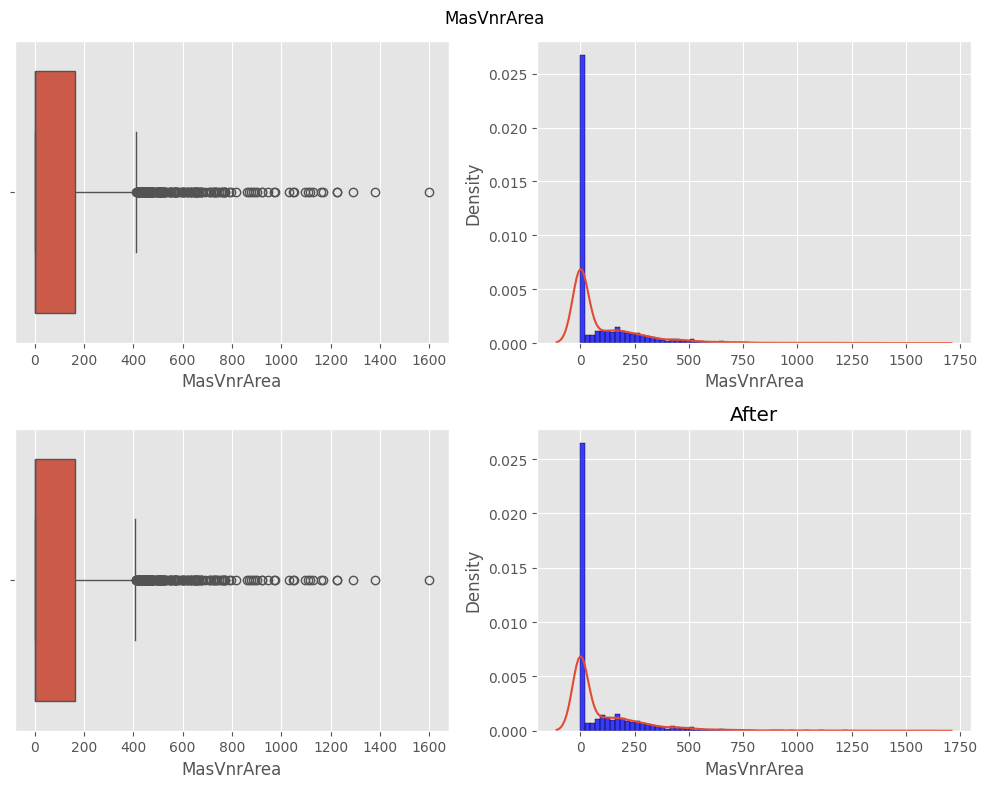

In [27]:
cont_MasVnrArea = df['MasVnrArea'].mean()
dfc['MasVnrArea'].fillna(cont_MasVnrArea, inplace=True)
BefvsAftNum('MasVnrArea')

##### Basement features

BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64
------
BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64
------
BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64
------
BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64
------
BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64
------


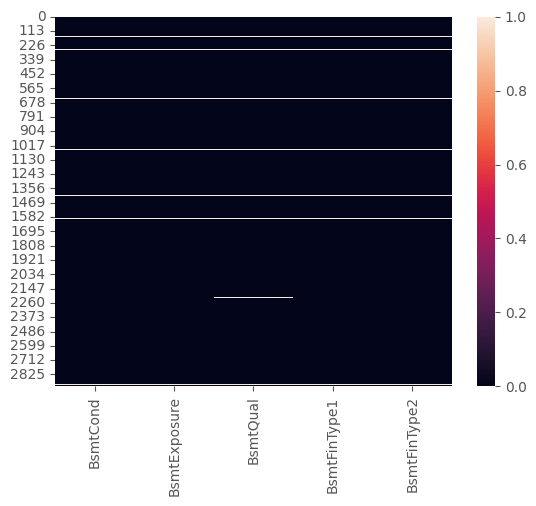

In [28]:
bsmt_float = ['BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF1', 'BsmtFinSF2', 'TotalBsmtSF', 'BsmtUnfSF'] 
bsmt_cat= ['BsmtCond', 'BsmtExposure', 'BsmtQual', 'BsmtFinType1', 'BsmtFinType2']

sns.heatmap(df[bsmt_cat].isnull())
for i in bsmt_cat:
    print(df[i].value_counts())
    print('------')

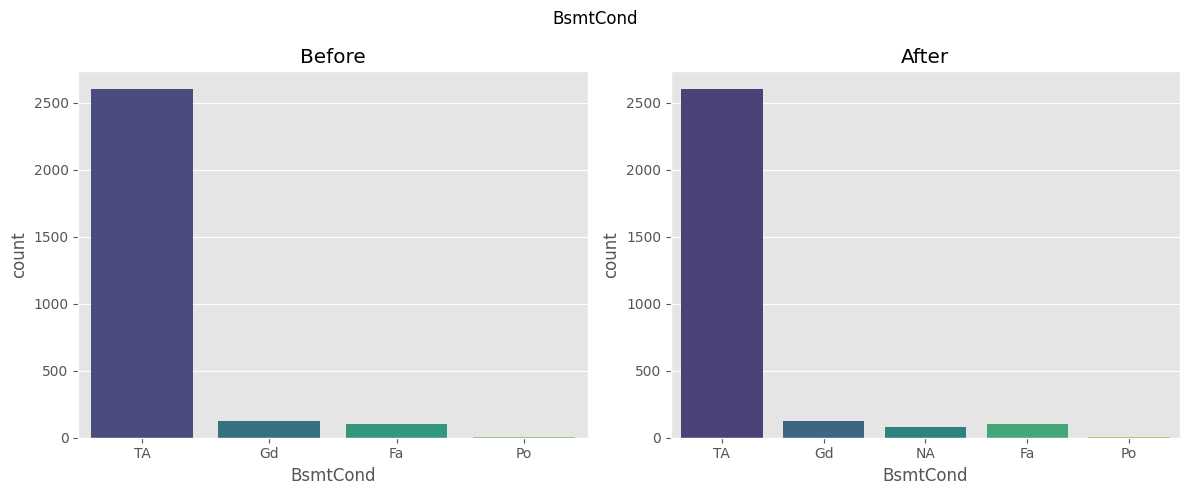

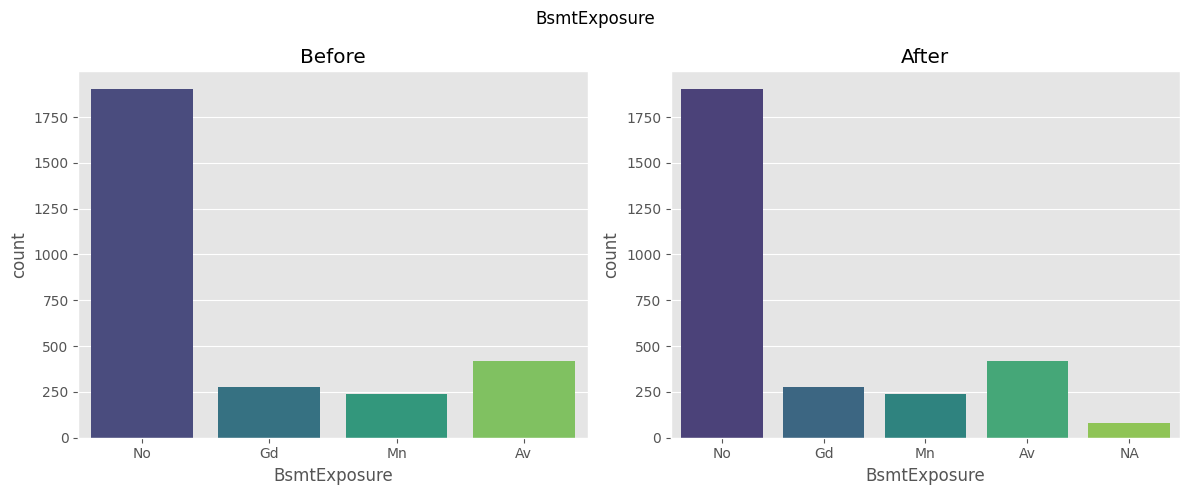

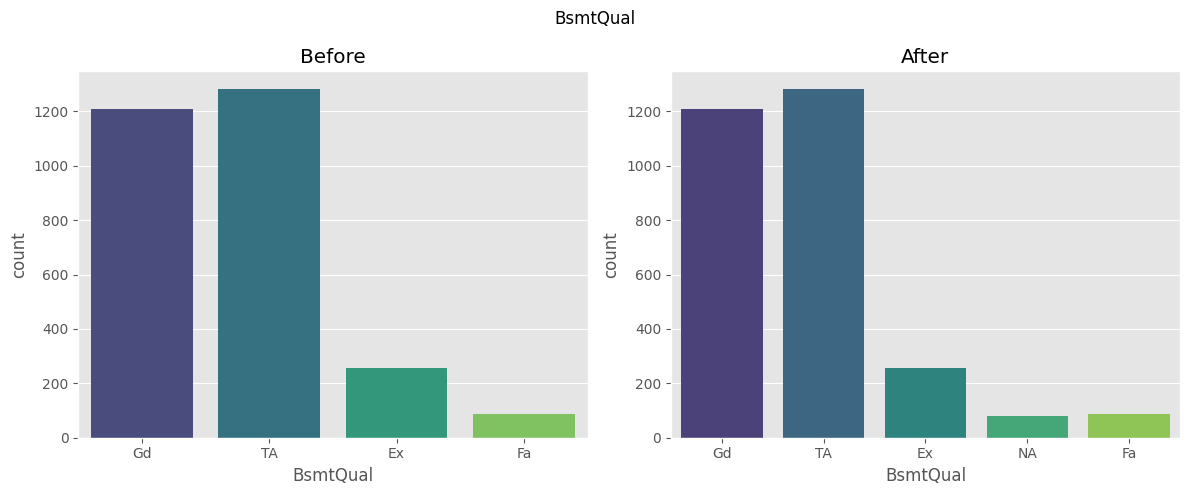

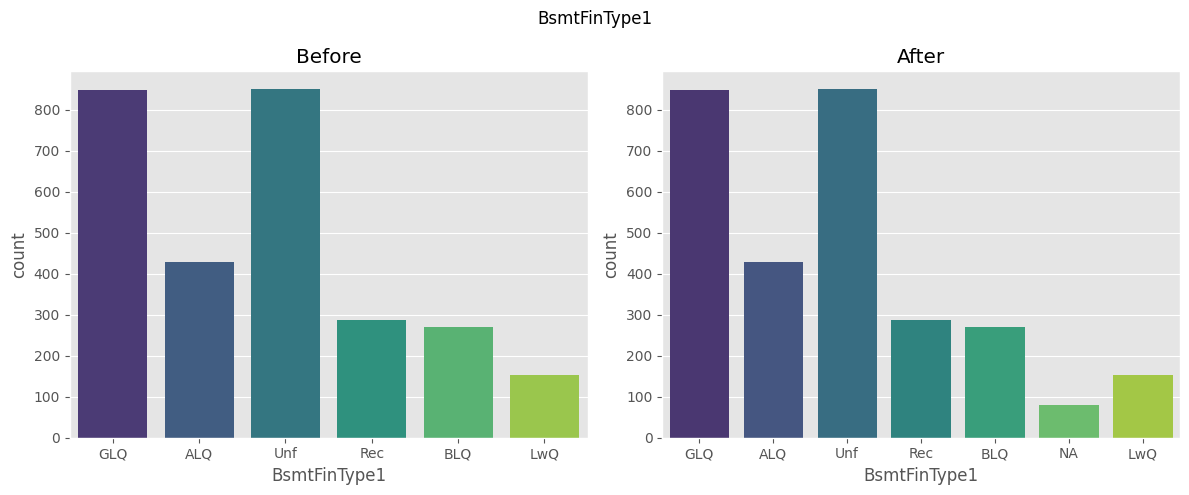

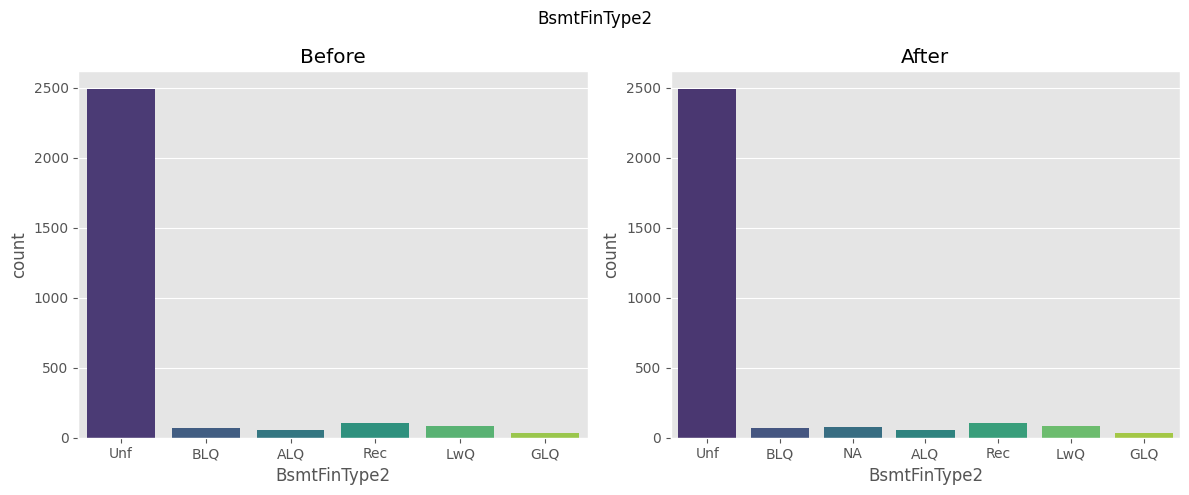

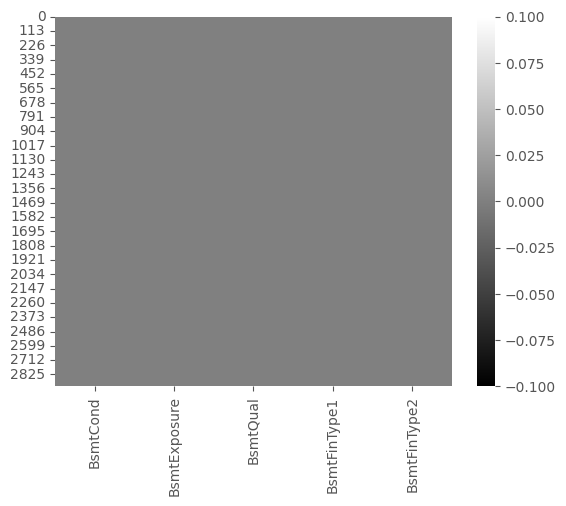

<Axes: >

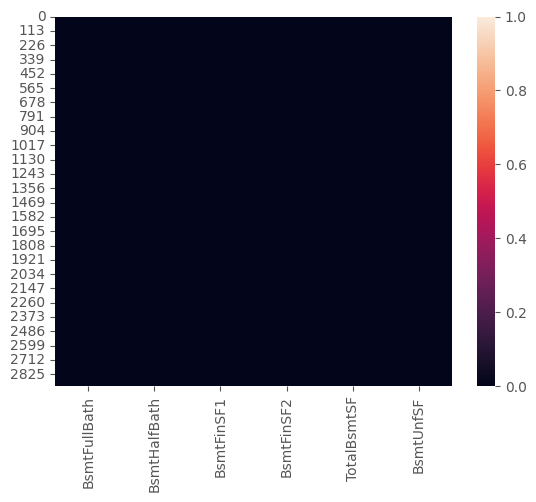

In [29]:
for i in bsmt_cat:
    dfc[i].fillna('NA', inplace=True)
    BefvsAft(i)
sns.heatmap(dfc[bsmt_cat].isnull(), cmap='gray')
plt.show()

sns.heatmap(dfc[bsmt_float].isnull())

##### Garage features

In [30]:
garage_float = ['GarageYrBlt', 'GarageCars', 'GarageArea']
garage_cat = ['GarageCond', 'GarageQual', 'GarageFinish', 'GarageType']

for i in garage_cat:
    print(df[i].value_counts())
    print('-----')

for i in garage_float:
    print(df[i].value_counts())
    print('-----')

GarageCond
TA    2654
Fa      74
Gd      15
Po      14
Ex       3
Name: count, dtype: int64
-----
GarageQual
TA    2604
Fa     124
Gd      24
Po       5
Ex       3
Name: count, dtype: int64
-----
GarageFinish
Unf    1230
RFn     811
Fin     719
Name: count, dtype: int64
-----
GarageType
Attchd     1723
Detchd      779
BuiltIn     186
Basment      36
2Types       23
CarPort      15
Name: count, dtype: int64
-----
GarageYrBlt
2005.0    142
2006.0    115
2007.0    115
2004.0     99
2003.0     92
         ... 
1896.0      1
1895.0      1
2207.0      1
1943.0      1
1919.0      1
Name: count, Length: 103, dtype: int64
-----
GarageCars
2.0    1594
1.0     776
3.0     374
0.0     157
4.0      16
5.0       1
Name: count, dtype: int64
-----
GarageArea
0.0      157
576.0     97
440.0     96
240.0     69
484.0     68
        ... 
217.0      1
323.0      1
265.0      1
609.0      1
272.0      1
Name: count, Length: 603, dtype: int64
-----


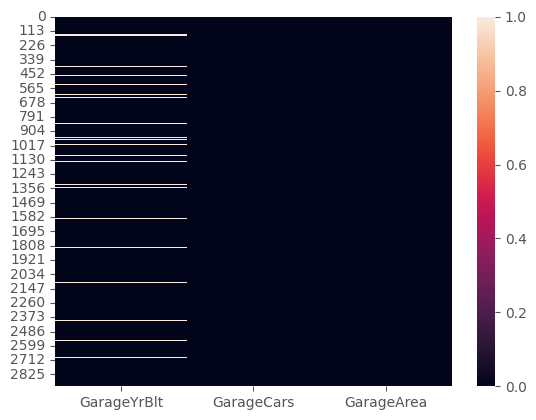

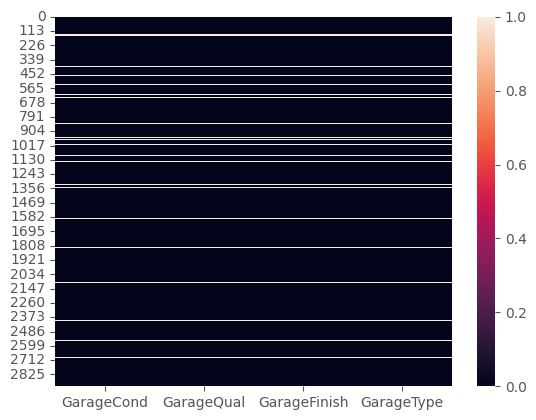

In [31]:
sns.heatmap(df[garage_float].isnull())
plt.show()
sns.heatmap(df[garage_cat].isnull())
plt.show()

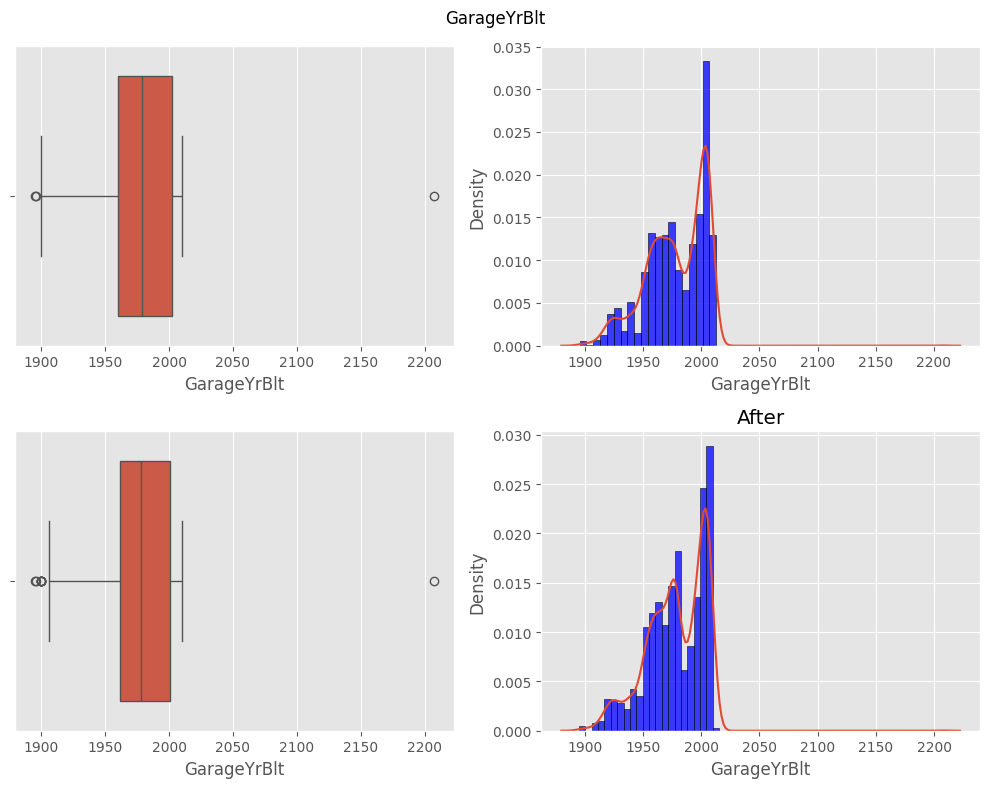

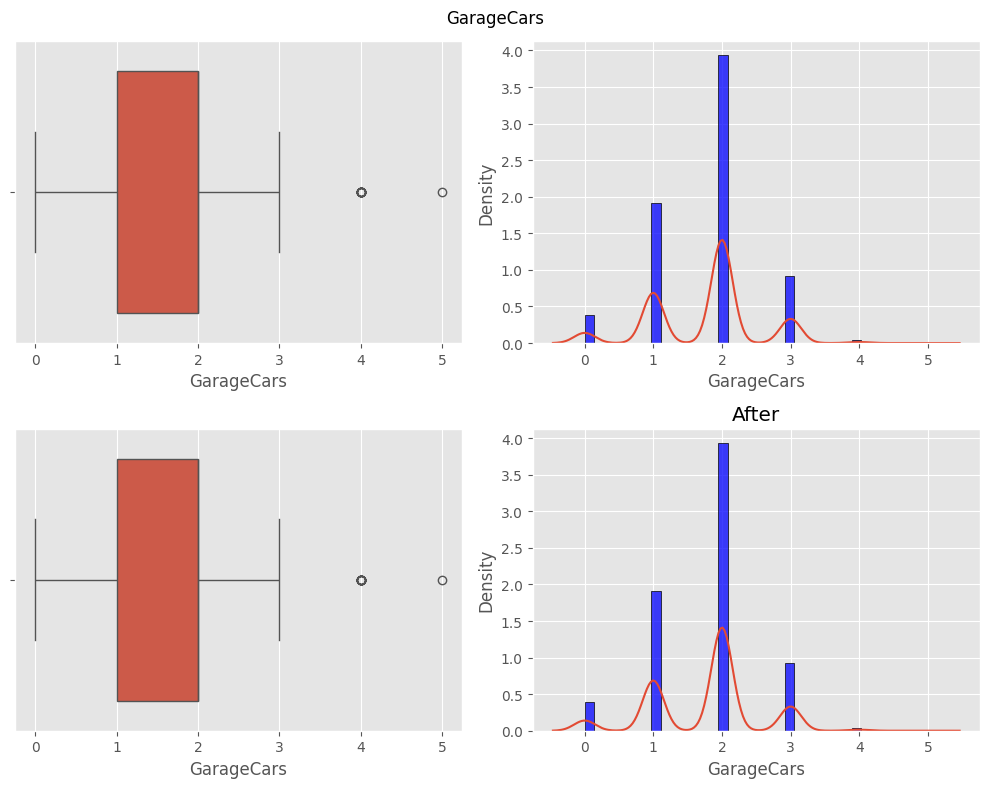

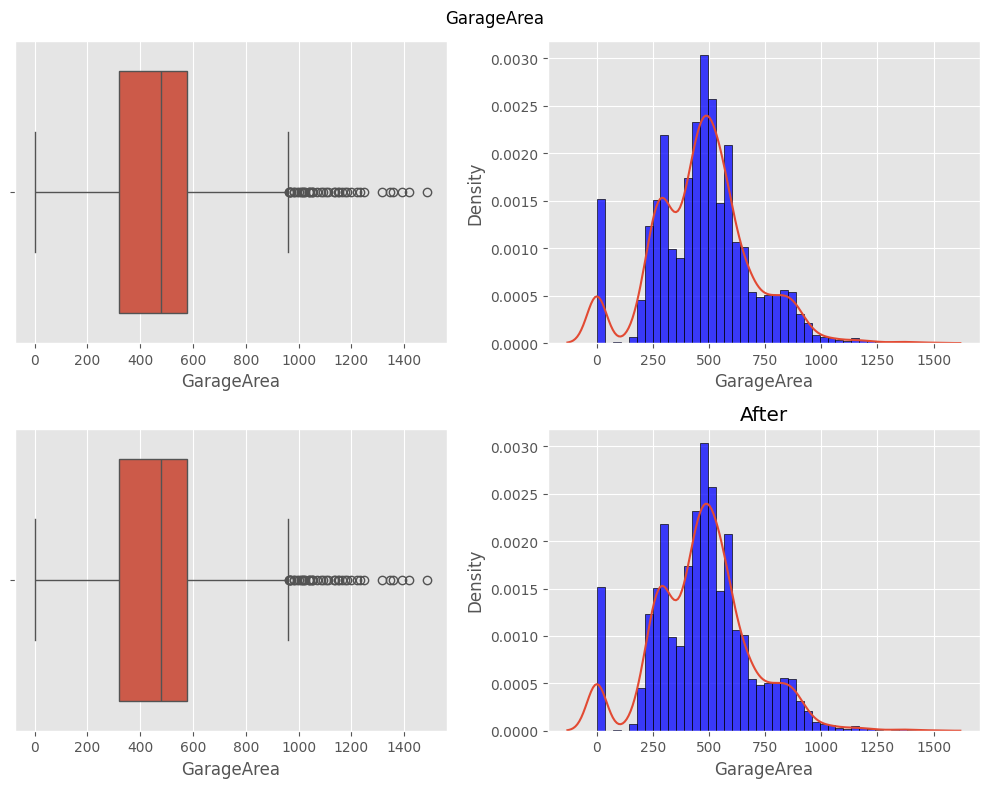

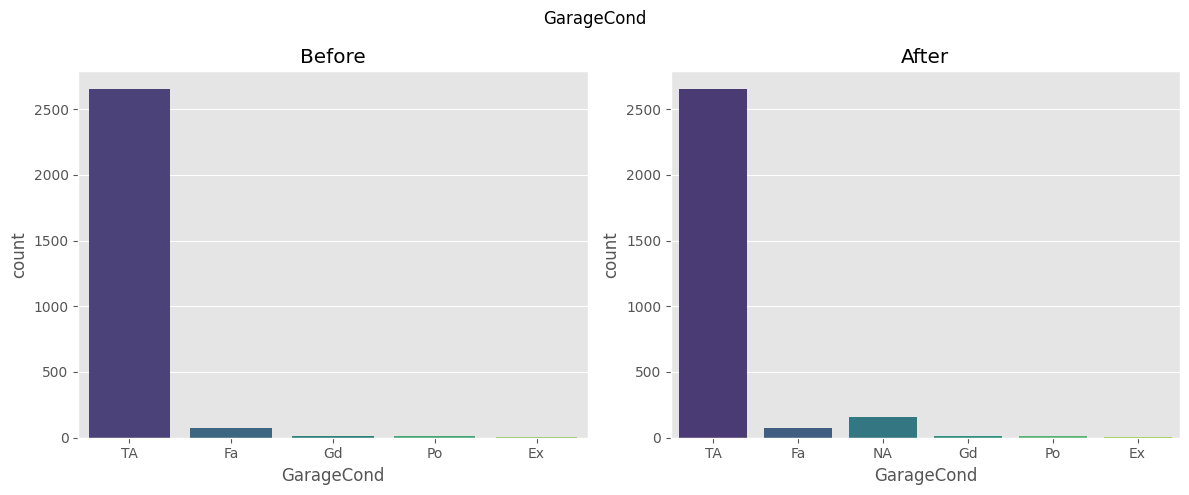

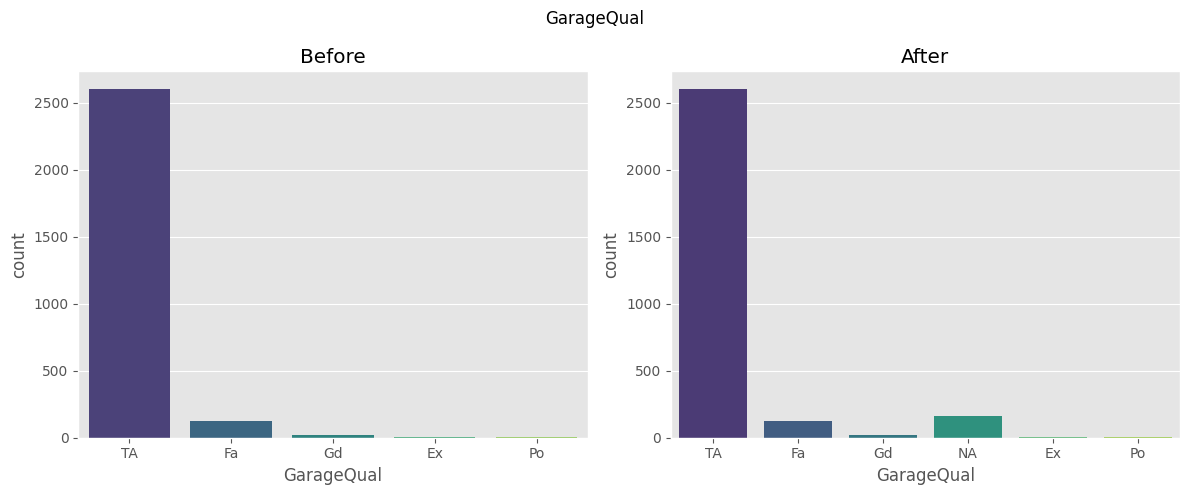

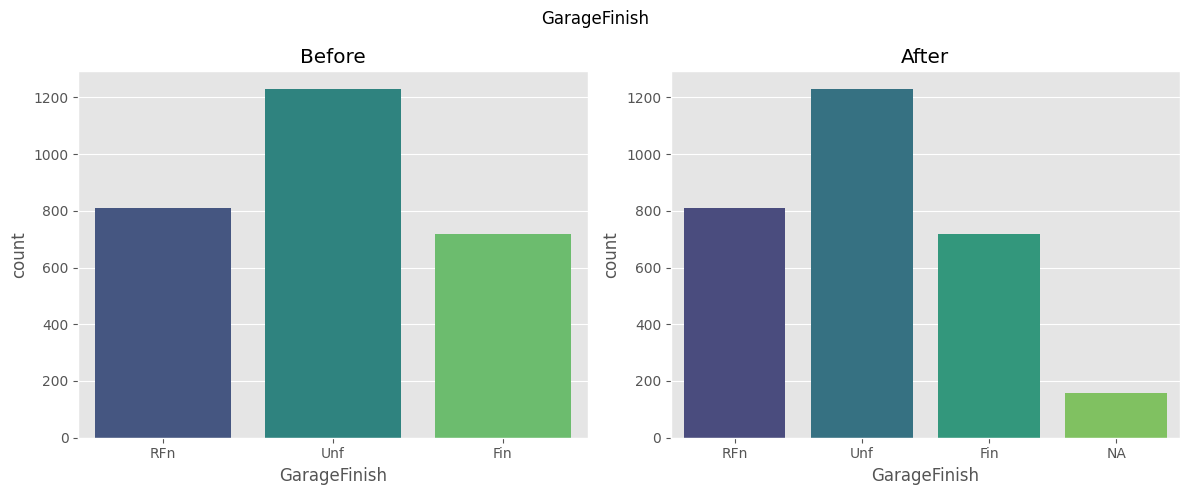

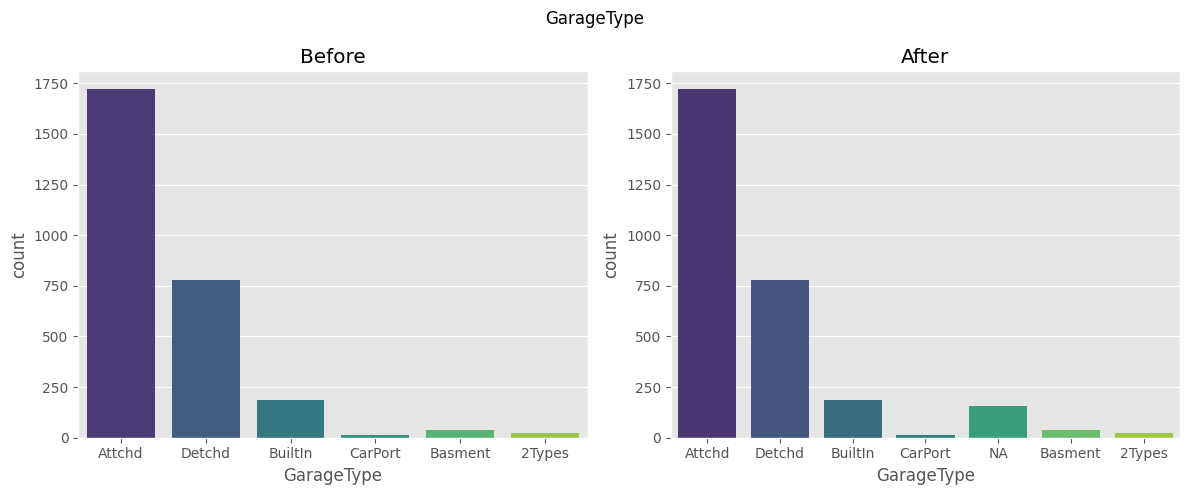

In [32]:
# GarageCars - mode
# GarageArea - mean
# GarageYrBlt - mean
# Every garage_cat - NA
dfc['GarageCars'].fillna(df['GarageCars'].mode()[0], inplace= True)
dfc['GarageArea'].fillna(df['GarageArea'].mean(), inplace=True)
dfc['GarageYrBlt'].fillna(int(df['GarageYrBlt'].mean()), inplace= True)
for i in garage_float:
    BefvsAftNum(i)
for i in garage_cat:
    dfc[i].fillna('NA', inplace=True)
    BefvsAft(i)

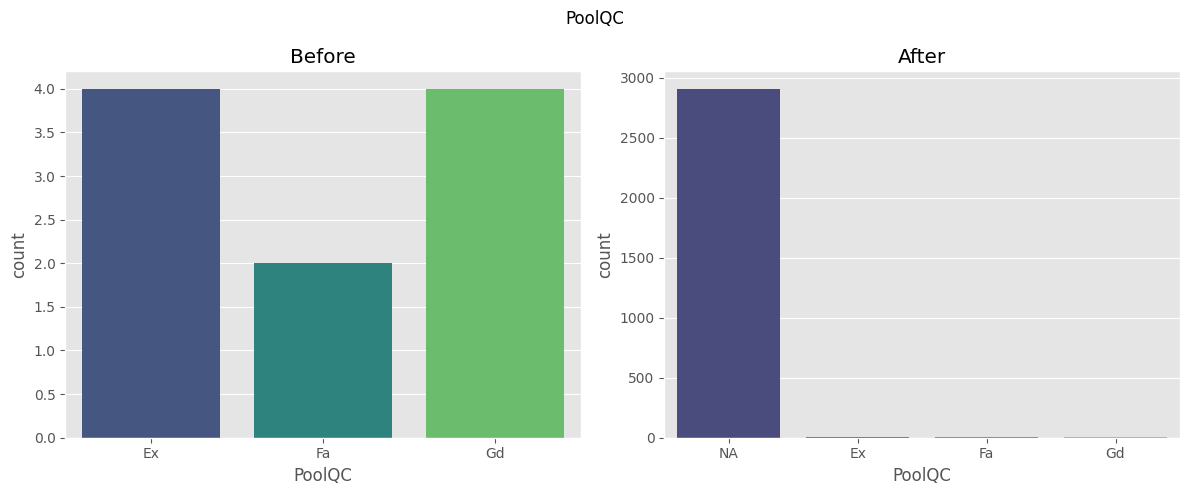

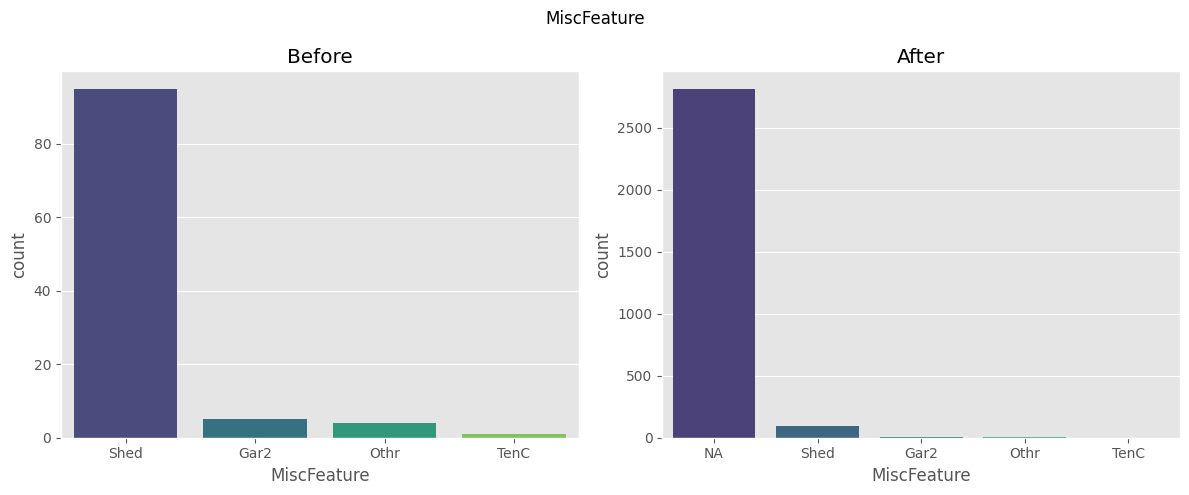

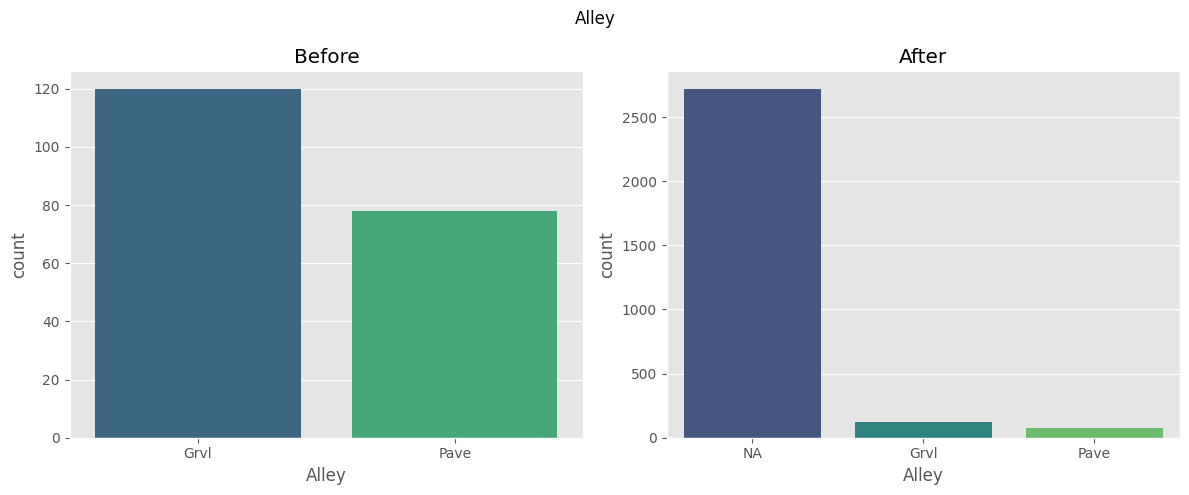

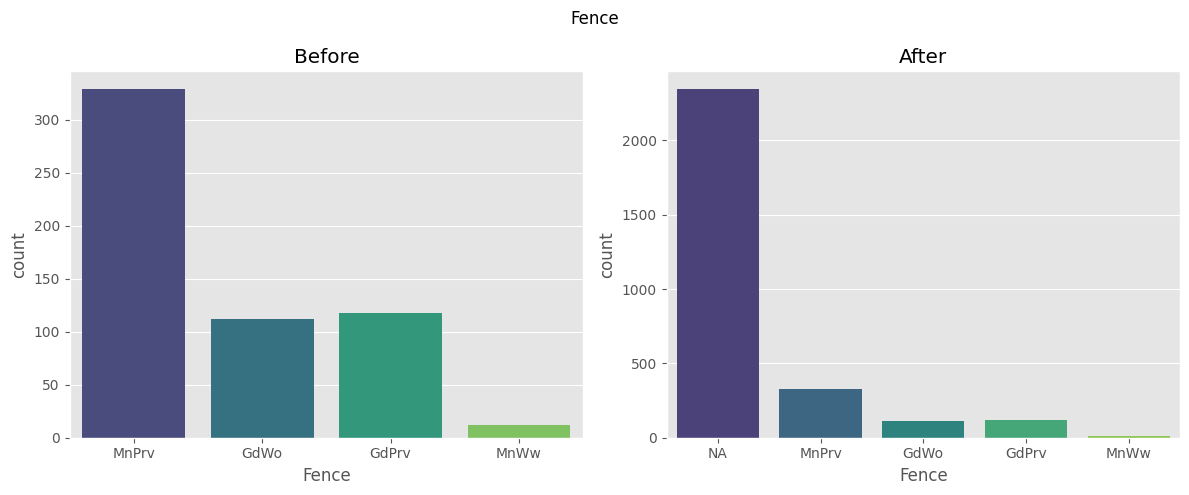

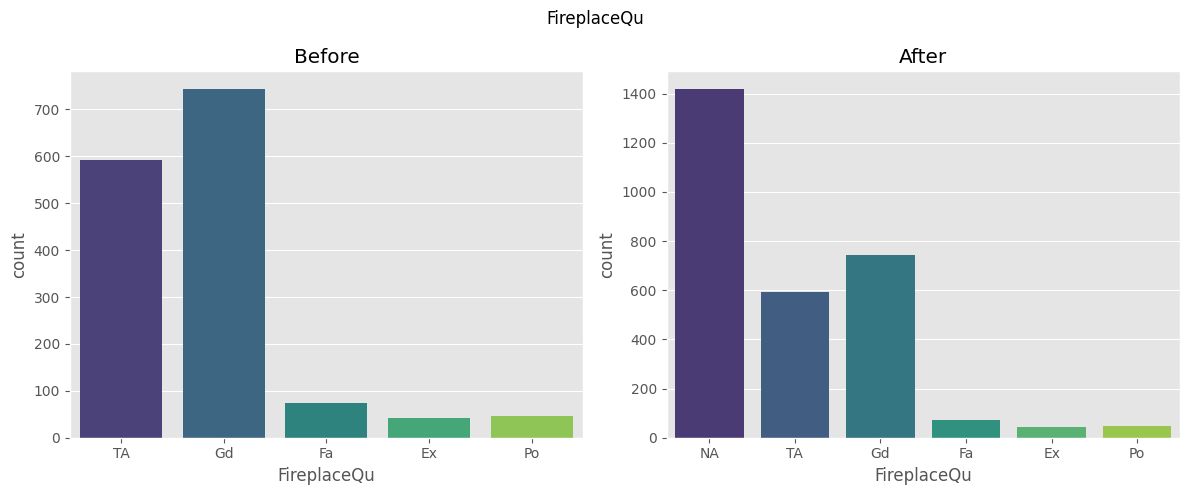

In [33]:
# PoolQC - NA
# MiscFeature - NA
# Alley - NA
# Fence - NA
# Fireplace - NA

other_feature = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu']

for i in other_feature:
    dfc[i].fillna('NA', inplace=True)
    BefvsAft(i)

##### Kitchen stuff

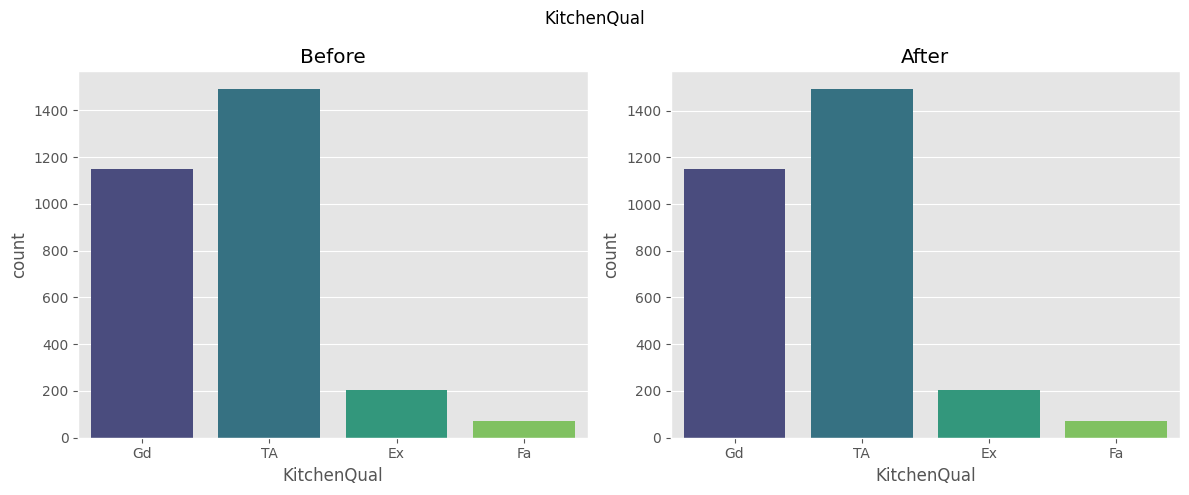

In [34]:
cont_kitchen = df['KitchenQual'].mode()[0]
dfc['KitchenQual'].fillna(cont_kitchen, inplace= True)
BefvsAft('KitchenQual')

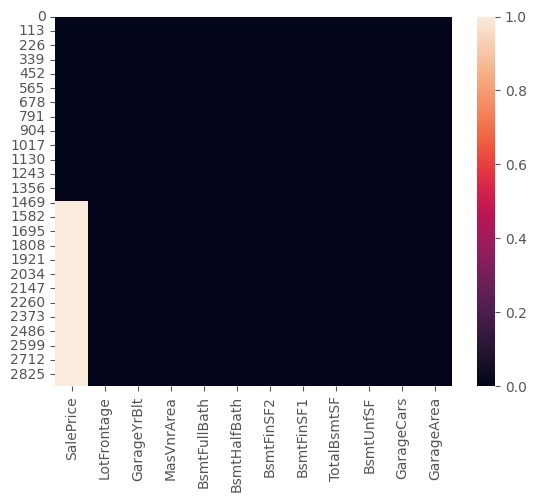

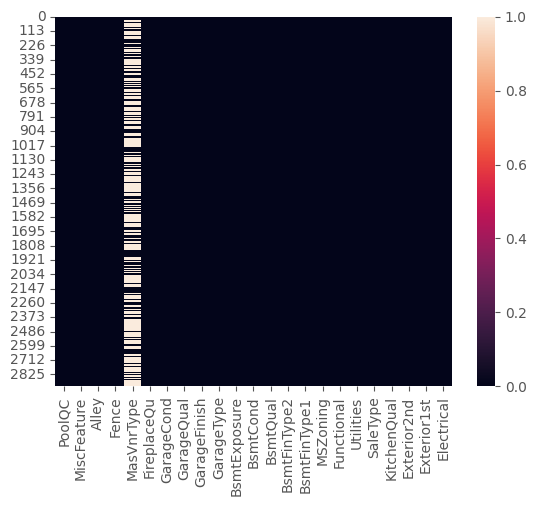

In [35]:
sns.heatmap(dfc[missing_float.index].isnull())
plt.show()

sns.heatmap(dfc[missing_cat.index].isnull())
plt.show()

In [36]:
df['MasVnrType'].value_counts()
dfc['MasVnrType'].fillna('NA', inplace= True)

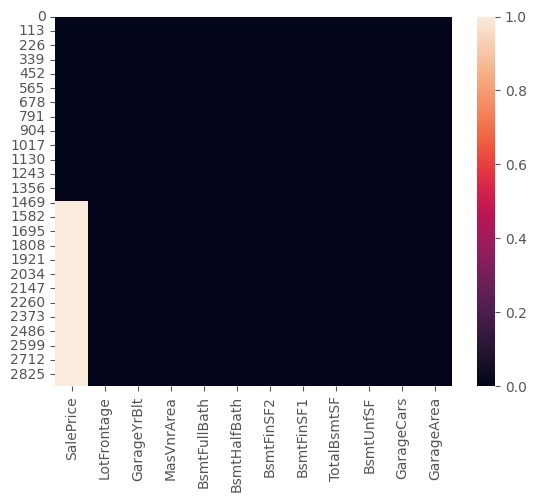

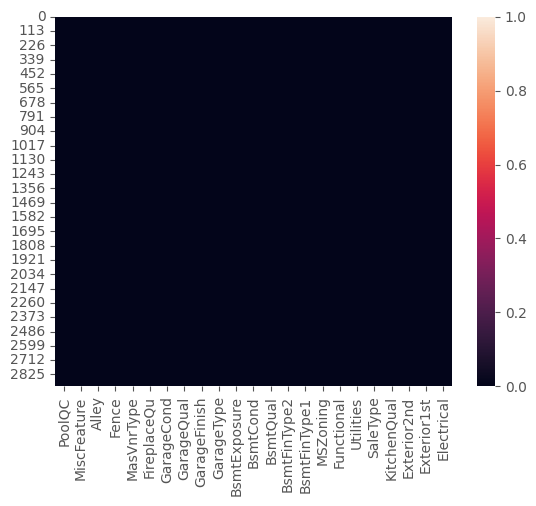

In [37]:
sns.heatmap(dfc[missing_float.index].isnull())
plt.show()

sns.heatmap(dfc[missing_cat.index].isnull())
plt.show()

In [38]:
dfc.isnull().sum().sort_values(ascending = False)

SalePrice        1459
BsmtFullBath        2
BsmtHalfBath        2
Functional          2
BsmtFinSF1          1
                 ... 
MiscFeature         0
MoSold              0
MiscVal             0
YrSold              0
SaleCondition       0
Length: 82, dtype: int64

1460 rows, 81 columns

No duplicate row

PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu and LotFrontage

Features that correlate with the SalePrice the most:

OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, Full Bath, TotRmsAbvGrd, YearBuilt, YearRemodAdd, GarageYrBlt

House with Fireplace, MasVnrType are more expensive

PoolQc is relevant

House with MiscFeature, Alley, Fence tend to cluster in the center

Drop MiscVal

Huge bsmt variations

Evaluation features: (havent been converted back to numebr eval)

ExterQual, ExterCond, BsmtQual, BsmtCond, Bsmt Exporsure, BsmtFinType1,
BsmtFinType2, HeatingQC, KitchenQual, Functional, FireplaceQu, GarageQual
GarageCond, PoolQc, Fence, 

## Onehot Encoding

In [39]:
y = data_train['SalePrice'].copy()
X__train = data_train.drop(columns=['SalePrice'], inplace=False).copy()

In [40]:
dummies = pd.get_dummies(dfc, columns = cat_features)

In [41]:
one_hot_feat = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'LotConfig', \
                'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', \
                'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', \
                'BsmtFinType1', 'BsmtFinType2', 'Heating', 'Electrical', 'Functional', 'GarageType',\
                'PavedDrive', 'MiscFeature', 'SaleType', 'SaleCondition']
ordinal_en_feat = ['Utilities', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'HeatingQC', 'CentralAir',\
                 'KitchenQual', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence']

In [42]:
ColTrans = ColumnTransformer(
    transformers=[
        ("one_hot", OneHotEncoder(handle_unknown="ignore", drop="first"), one_hot_feat),
        ("label", OrdinalEncoder(handle_unknown = 'error', encoded_missing_value=np.nan), ordinal_en_feat)
    ]
)

df_trans = pd.DataFrame(ColTrans.fit_transform(dfc).toarray(), columns= ColTrans.get_feature_names_out())

In [43]:

for i in ordinal_en_feat:
    s = 'label__' + i 
    dfc[i] = df_trans[s]

# Exploratory data analysis

## Some Basic information

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 82 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          2919 non-null   int64  
 1   Id             2919 non-null   int64  
 2   MSSubClass     2919 non-null   int64  
 3   MSZoning       2915 non-null   object 
 4   LotFrontage    2433 non-null   float64
 5   LotArea        2919 non-null   int64  
 6   Street         2919 non-null   object 
 7   Alley          198 non-null    object 
 8   LotShape       2919 non-null   object 
 9   LandContour    2919 non-null   object 
 10  Utilities      2917 non-null   object 
 11  LotConfig      2919 non-null   object 
 12  LandSlope      2919 non-null   object 
 13  Neighborhood   2919 non-null   object 
 14  Condition1     2919 non-null   object 
 15  Condition2     2919 non-null   object 
 16  BldgType       2919 non-null   object 
 17  HouseStyle     2919 non-null   object 
 18  OverallQ

In [45]:
df.describe()

,index,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,729.250086,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,421.393596,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,0.000000,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,364.500000,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,729.000000,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1094.000000,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1459.000000,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


## Data visualization

### Categorical features

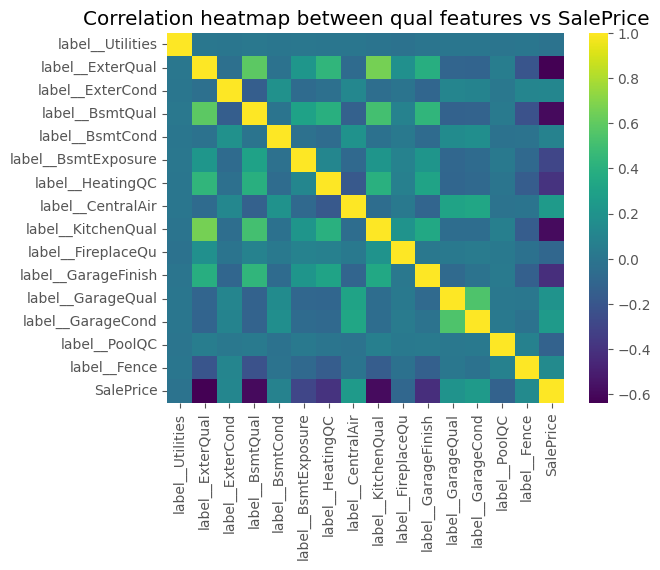

In [46]:
df_trans_label = df_trans.filter(regex='^label')
corr0 = pd.concat([df_trans_label, y],axis=1).corr()
sns.heatmap(corr0, cmap='viridis')
plt.title('Correlation heatmap between qual features vs SalePrice')
plt.show()

In [47]:
pos_feat_cat= corr0.loc[corr0['SalePrice'] > 0.3].index.tolist()
neg_feat_cat = corr0.loc[corr0['SalePrice'] < -0.3].index.tolist()


In [48]:
print(pos_feat_cat)
print(neg_feat_cat)

['SalePrice']
['label__ExterQual', 'label__BsmtQual', 'label__HeatingQC', 'label__KitchenQual', 'label__GarageFinish']


- Negatively correlated categorical features: ExterQual, BsmtQual, HeatingQC, KitchenQual, Garage Finish

### Numerical features

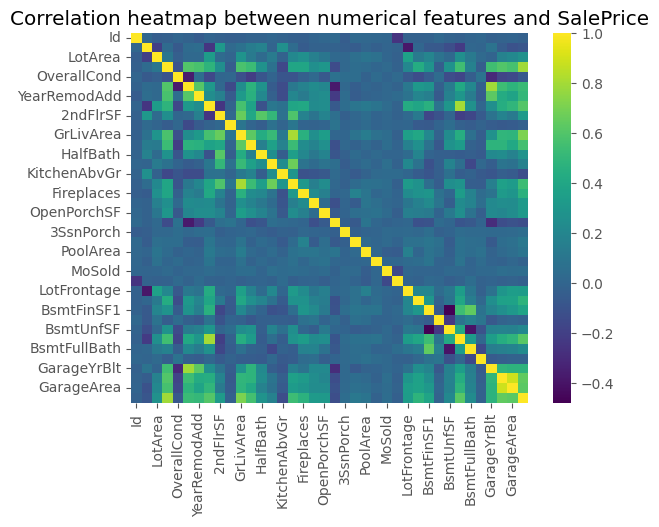

In [49]:
corr1 = dfc[num_features].corr()
sns.heatmap(corr1, cmap='viridis')
plt.title('Correlation heatmap between numerical features and SalePrice')
plt.show()

In [50]:
print(corr1['SalePrice'].sort_values(ascending=False))
print(corr1['SalePrice'].sort_values())

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.475210
GarageYrBlt      0.471316
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334544
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

- Highest correlated numerical features: OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, 1stFlrSF, FullBath,
TotRmsAbvGrd, YearBuilt, YearRemodAdd, GarageYrBlr, MasVnrArea, Fireplaces, BsmtFinSF2, LotFontage, WoodDeckSF, 2ndFlrSF, 
OpenPorchSF

## Groupby stuff

In [51]:
dfc.set_index('Id')
dfc.drop(columns='index')

dfa = dfc.copy()

In [52]:
dfa.groupby('YrSold')['SalePrice'].mean().reset_index()

,YrSold,SalePrice
0,2006,182549.458599
1,2007,186063.151976
2,2008,177360.838816
3,2009,179432.103550
4,2010,177393.674286


In [53]:
dfa.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

In [54]:
dfa.groupby('OverallQual')['SalePrice'].mean()

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

In [55]:
dfa.groupby('SaleCondition')['SalePrice'].mean()

SaleCondition
Abnorml    146526.623762
AdjLand    104125.000000
Alloca     167377.416667
Family     149600.000000
Normal     175202.219533
Partial    272291.752000
Name: SalePrice, dtype: float64

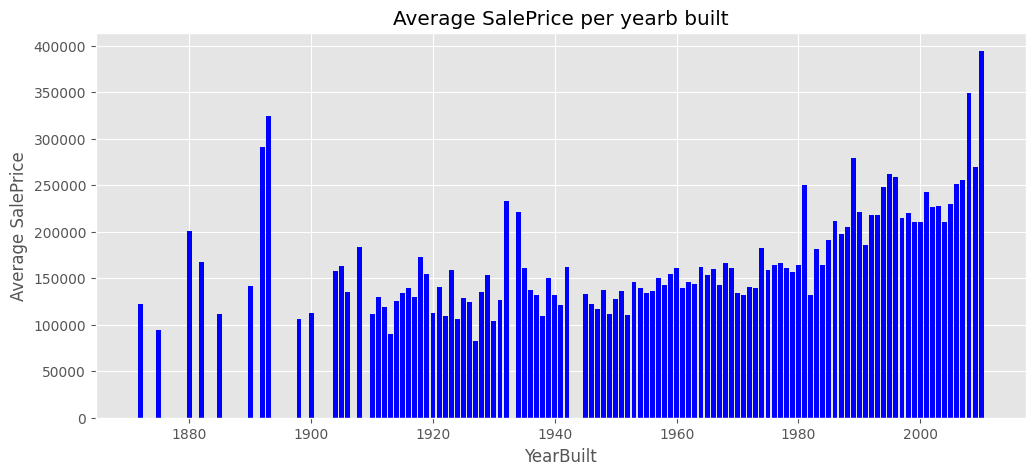

In [56]:
yrblt = dfa.groupby(['YearBuilt'])['SalePrice'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize = (12, 5))

plt.bar(yrblt['YearBuilt'], yrblt['SalePrice'], color = 'blue')
plt.xlabel('YearBuilt')
plt.ylabel('Average SalePrice')
plt.title('Average SalePrice per yearb built')
plt.show()

In [57]:
dfa.groupby('Condition1')['SalePrice'].mean()

Condition1
Artery    135091.666667
Feedr     142475.481481
Norm      184495.492063
PosA      225875.000000
PosN      215184.210526
RRAe      138400.000000
RRAn      184396.615385
RRNe      190750.000000
RRNn      212400.000000
Name: SalePrice, dtype: float64

In [58]:
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    print(discrete_features)
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

# Split data

In [59]:
len_train = data_train.shape[0]
len_train

1460

In [60]:
X_train = df_trans[:len_train]
y_train = data_train['SalePrice']
x_test = df_trans[len_train:]

In [61]:
StanScal = StandardScaler()
StanScal.fit(X_train)
StanScal.fit(x_test)


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


# Machine learning implementation

In [62]:
svr = SVR()
lr = LinearRegression()
sgdr = SGDRegressor()
knn = KNeighborsRegressor()
gpr = GaussianProcessRegressor()
dtr = DecisionTreeRegressor()
rfr = RandomForestRegressor()
gbr = GradientBoostingRegressor()
xgbr = XGBRegressor()

mlpr = MLPRegressor()

In [63]:
models = {"a":["LinearRegression",lr],
          "b":["SVR",svr],
          "c":["SGDRegressor",sgdr],
          "d":["KNeighborsRegressor",knn],
          "e":["GaussianProcessRegressor",gpr],
          "f":["DecisionTreeRegressor",dtr],
          "g":["GradientBoostingRegressor",gbr],
          "h":["RandomForestRegressor",rfr],
          "i":["XGBRegressor",xgbr],
          "j":["MLPRegressor",mlpr],
          }    # Create a dictionary to store the results

In [64]:
def test_model(model, X_train=X_train,y_train=y_train):
    cv = KFold(n_splits=7, random_state=45, shuffle=True)
    r2 = make_scorer(r2_score)
    r2_val_score = cross_val_score(model, X_train, y_train, cv=cv, scoring=r2)
    score = [r2_val_score.mean()]
    return score

In [65]:
models_score=[]
for model in models:
    print("Model Name: ",models[model][0])
    score = test_model(models[model][1], X_train, y_train)
    print("Score of Model:",score)
    print("-----------------------")
    models_score.append([models[model][0],score])

Model Name:  LinearRegression
Score of Model: [np.float64(0.6820977528012572)]
-----------------------
Model Name:  SVR
Score of Model: [np.float64(-0.051715635494555726)]
-----------------------
Model Name:  SGDRegressor
Score of Model: [np.float64(0.7271651651536691)]
-----------------------
Model Name:  KNeighborsRegressor
Score of Model: [np.float64(0.656277851928844)]
-----------------------
Model Name:  GaussianProcessRegressor
Score of Model: [np.float64(-4.080290849554848)]
-----------------------
Model Name:  DecisionTreeRegressor
Score of Model: [np.float64(0.4848091211276052)]
-----------------------
Model Name:  GradientBoostingRegressor
Score of Model: [np.float64(0.7548824247541306)]
-----------------------
Model Name:  RandomForestRegressor
Score of Model: [np.float64(0.7342922747477997)]
-----------------------
Model Name:  XGBRegressor
Score of Model: [np.float64(0.7621623533112662)]
-----------------------
Model Name:  MLPRegressor
Score of Model: [np.float64(-4.46037

In [66]:
gbr.fit(X_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [67]:
y_pred=gbr.predict(x_test)

In [68]:
# y_pred # is a numpy array hence we gonna convert it into dataframe
y_pred=pd.concat([data_test['Id'],pd.DataFrame(y_pred,columns=['SalePrice'])],axis=1)
y_pred

,Id,SalePrice
0,1461,121580.758393
1,1462,153918.467454
2,1463,186575.824159
3,1464,186388.719532
4,1465,180240.169097
...,...,...
1454,2915,81439.220253
1455,2916,89018.241786
1456,2917,137927.647018
1457,2918,131404.884987


In [ ]:
res_path = 'D:/Programming/Housing Prices Predication using machin learning/result.csv'
y_pred.to_csv(res_path,index=False)

: 